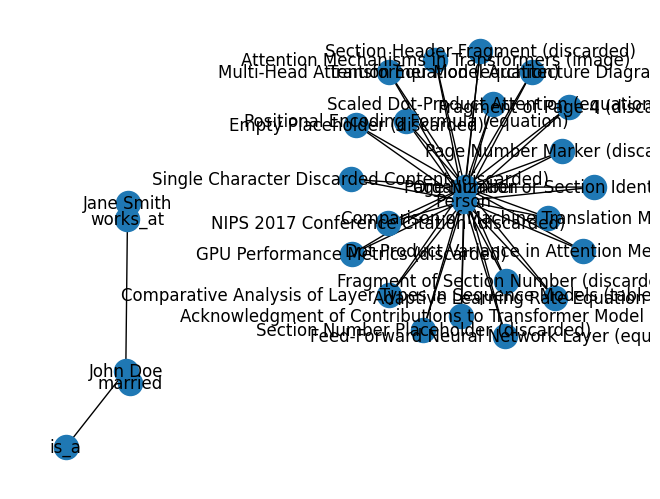

In [2]:
import networkx as nx
import matplotlib.pyplot as plt

G = nx.read_graphml("/Users/qtf4195/tum-hackathon/rag_storage_gpt-4o-mini_text-embedding-3-large_mineru_temp0.0_max4k_retry3_5/graph_chunk_entity_relation.graphml")
nx.draw(G, with_labels=True)
plt.show()


In [4]:
import networkx as nx
G = nx.read_graphml("/Users/qtf4195/tum-hackathon/rag_storage_simple/graph_chunk_entity_relation.graphml")
print(G.nodes(), G.edges())

['Transformer model architecture (discarded)', 'unknown_entity (unknown)', 'Transformer Model Architecture (image)', 'Technical Illustration of Transformer Attention Mechanisms (image)', 'Scaled Dot-Product Attention (equation)', 'Theoretical Explanation of Dot Products in Attention Mechanisms (discarded)', 'Transformer architecture and attention mechanisms (discarded)', 'Multi-Head Attention Mechanism (equation)', 'Feed-Forward Network Activation Function (equation)', 'discarded content (discarded)', 'Maximum path lengths, complexity per layer and sequential operations for different layer types (table)', 'Positional Encoding Equation (equation)', 'Learning Rate Schedule for Adam Optimizer (equation)', 'Table 2: BLEU scores and training costs for different models (table)', 'Computational Resources for Training Deep Learning Models (discarded)'] []


In [1]:
import networkx as nx
G = nx.read_graphml("/Users/qtf4195/tum-hackathon/rag_storage_gpt-4o-mini_text-embedding-3-large_mineru_temp0.0_max4k_retry3_5/graph_chunk_entity_relation.graphml")
print(len(G.nodes()), "nodes")
print(len(G.edges()), "edges")

28 nodes
46 edges


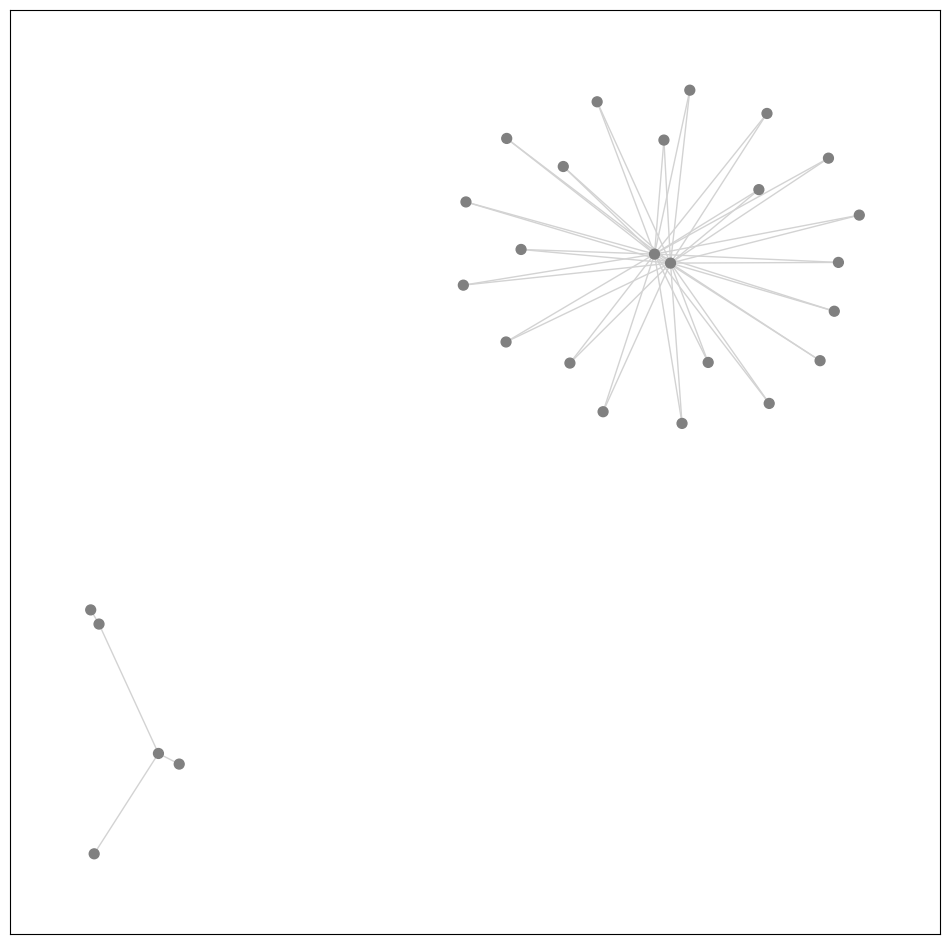

In [3]:
import networkx as nx
import matplotlib.pyplot as plt

graph_path = "/Users/qtf4195/tum-hackathon/rag_storage_gpt-4o-mini_text-embedding-3-large_mineru_temp0.0_max4k_retry3_5/graph_chunk_entity_relation.graphml"
G = nx.read_graphml(graph_path)

plt.figure(figsize=(12,12))
pos = nx.spring_layout(G, k=0.15)  # Force-layout
node_colors = [ 'red' if G.nodes[n].get('type')=='figure'
                else 'blue' if G.nodes[n].get('type')=='table'
                else 'grey'
                for n in G.nodes()]
nx.draw_networkx(G, pos, node_size=50, node_color=node_colors,
                 with_labels=False, edge_color='lightgrey')
plt.show()

In [4]:
# visualize_rag_graph.py

import networkx as nx
from pyvis.network import Network
import os

# Adjust these paths:
GRAPH_PATH = "/Users/qtf4195/tum-hackathon/rag_storage_gpt-4o-mini_text-embedding-3-large_mineru_temp0.0_max4k_retry3_5/graph_chunk_entity_relation.graphml"  # or .gexf/.json depending on your output
OUTPUT_HTML = "/Users/qtf4195/tum-hackathon/output_gpt-4o-mini_text-embedding-3-large_mineru_temp0.0_max4k_retry3_5"

def load_graph(path):
    ext = os.path.splitext(path)[1].lower()
    if ext == ".graphml":
        return nx.read_graphml(path)
    elif ext == ".gexf":
        return nx.read_gexf(path)
    else:
        raise ValueError(f"Unsupported graph format: {ext}")

def visualize_graph(G, output_html):
    net = Network(height="800px", width="100%", notebook=False)
    net.force_atlas_2based()  # layout algorithm
    net.from_nx(G)

    # Optionally: set node colors or sizes based on attributes:
    for n, d in G.nodes(data=True):
        node_type = d.get("type", "unknown")
        if node_type == "figure":
            net.get_node(n)["color"] = "blue"
        elif node_type == "table":
            net.get_node(n)["color"] = "green"
        elif node_type == "equation":
            net.get_node(n)["color"] = "red"
        else:
            net.get_node(n)["color"] = "grey"

        # size by degree (number of connections)
        net.get_node(n)["size"] = max(10, G.degree(n) * 2)

        # tooltip / title show snippet
        snippet = d.get("content", d.get("caption", ""))
        net.get_node(n)["title"] = snippet

    net.show(output_html)
    print(f"Graph visualization exported to {output_html}")

def main():
    print("Loading graph …")
    G = load_graph(GRAPH_PATH)
    print("Nodes:", G.number_of_nodes(), "Edges:", G.number_of_edges())
    print("Visualizing …")
    visualize_graph(G, OUTPUT_HTML)

if __name__ == "__main__":
    main()


ModuleNotFoundError: No module named 'pyvis'